In [ ]:
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np
import joblib
import warnings
import os
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/unemployment_project/raw_data'


Mounted at /content/drive


In [ ]:
# SECTION 1: DATA LOADING

gender_data = pd.read_csv(f'{base_path}/Unemployment-Rate-by-Gender.csv')
print(f"Gender data: {len(gender_data)} records")

# Filter Total only
data = gender_data[
    gender_data['Gender'] == 'Total'
].sort_values('Quarter').reset_index(drop=True)

print(f"Total records: {len(data)}")
print(data.head() )

Gender data: 117 records
Total records: 39
   Quarter Gender  Unemployment Rate
0  2016-Q2  Total               11.6
1  2016-Q3  Total               12.1
2  2016-Q4  Total               12.3
3  2017-Q1  Total               12.7
4  2017-Q2  Total               12.8


In [ ]:
# SECTION 2: SCHEMA VALIDATION
print("Columns:", data.columns.tolist())
print("Data types:")
print(data.dtypes)
print("Data shape:", data.shape)
print("Date range:", data['Quarter'].min(), "to", data['Quarter'].max())

Columns: ['Quarter', 'Gender', 'Unemployment Rate']
Data types:
Quarter               object
Gender                object
Unemployment Rate    float64
dtype: object
Data shape: (39, 3)
Date range: 2016-Q2 to 2025-Q4


In [ ]:
# SECTION 3: MISSING VALUE HANDLING

print("Missing values:")
print(data.isnull().sum())


Missing values:
Quarter              0
Gender               0
Unemployment Rate    0
dtype: int64


In [ ]:
Q1 = data['Unemployment Rate'].quantile(0.25)
Q3 = data['Unemployment Rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['Unemployment Rate'] < lower_bound) |
    (data['Unemployment Rate'] > upper_bound)
]

print(f"Q1: {Q1:.2f}% | Q3: {Q3:.2f}% | IQR: {IQR:.2f}%")
print(f"Normal range: {lower_bound:.2f}% to {upper_bound:.2f}%")
print(f"Outliers detected: {len(outliers)}")



Q1: 8.33% | Q3: 12.65% | IQR: 4.32%
Normal range: 1.86% to 19.13%
Outliers detected: 0


In [ ]:

data['Gender'] = data['Gender'].str.strip()


In [ ]:
# Sort by date
data = data.sort_values('Quarter').reset_index(drop=True)

# Lag features
data['Lag_1']          = data['Unemployment Rate'].shift(1)
data['Lag_4']          = data['Unemployment Rate'].shift(4)

# Rolling average
data['Rolling_Mean_4'] = data['Unemployment Rate'].rolling(window=4, min_periods=1).mean()

# Year-over-year change
data['YoY_Change']     = data['Unemployment Rate'] - data['Lag_4']

# Target: next quarter unemployment rate
data['Target']         = data['Unemployment Rate'].shift(-1)

# Remove NaN after creating all features and target
data = data.dropna()
print(f"Records after removing NaN: {len(data)}")

Records after removing NaN: 34


In [ ]:
# SECTION 7: SPLITTING

# 70/15/15 for Linear Regression and Random Forest
train_size = int(len(data) * 0.70)
val_size   = int(len(data) * 0.15)

train_data = data.iloc[:train_size].copy()
val_data   = data.iloc[train_size:train_size + val_size].copy()
test_data  = data.iloc[train_size + val_size:].copy()

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# 70/30 for SARIMA — uses original rates before feature engineering
rates        = gender_data[gender_data['Gender'] == 'Total'].sort_values('Quarter')['Unemployment Rate'].values
train_size_s = int(len(rates) * 0.70)
train_s      = rates[:train_size_s]
test_s       = rates[train_size_s:]

print(f"SARIMA Train: {len(train_s)} | Test: {len(test_s)}")


Train: 23 | Val: 5 | Test: 6
SARIMA Train: 27 | Test: 12


In [ ]:
# SECTION 8: SCALING (RobustScaler — fit on train only)

scale_columns = ['Unemployment Rate', 'Lag_1', 'Lag_4', 'Rolling_Mean_4', 'YoY_Change']
scaler        = RobustScaler()

train_scaled = train_data.copy()
val_scaled   = val_data.copy()
test_scaled  = test_data.copy()

train_scaled[scale_columns] = scaler.fit_transform(train_data[scale_columns])
val_scaled[scale_columns]   = scaler.transform(val_data[scale_columns])
test_scaled[scale_columns]  = scaler.transform(test_data[scale_columns])

features = ['Unemployment Rate', 'Lag_1', 'Lag_4', 'Rolling_Mean_4', 'YoY_Change']

X_train = train_scaled[features]
y_train = train_data['Target']
X_val   = val_scaled[features]
y_val   = val_data['Target']
X_test  = test_scaled[features]
y_test  = test_data['Target']

In [ ]:
# SECTION 9: BASELINE MODEL (Linear Regression)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_val)
baseline_mae    = mean_absolute_error(y_val, y_pred_baseline)
baseline_rmse   = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
baseline_r2     = r2_score(y_val, y_pred_baseline)

print("Baseline (Linear Regression) — Validation Results:")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline (Linear Regression) — Validation Results:
MAE  : 0.4355
RMSE : 0.4960
R²   : 0.3435


In [ ]:
# Default Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_val   = rf_model.predict(X_val)
y_pred_rf_test  = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train)

print("Random Forest — Default:")
print(f"Train MAE : {mean_absolute_error(y_train, y_pred_rf_train):.4f}")
print(f"Val   MAE : {mean_absolute_error(y_val, y_pred_rf_val):.4f}")
print(f"Test  MAE : {mean_absolute_error(y_test, y_pred_rf_test):.4f}")
print(f"Test  R²  : {r2_score(y_test, y_pred_rf_test):.4f}")


Random Forest — Default:
Train MAE : 0.3039
Val   MAE : 0.9605
Test  MAE : 1.8941
Test  R²  : -15.8802


In [ ]:
importance = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (RF Default):")
print(importance)


Feature Importance (RF Default):
             Feature  Importance
3     Rolling_Mean_4    0.328637
0  Unemployment Rate    0.304072
1              Lag_1    0.251260
4         YoY_Change    0.077675
2              Lag_4    0.038357


In [ ]:
# (Random Forest + Tuning)

# Tuned Random Forest — cv=3 مناسب للبيانات الصغيرة
param_grid = {
    'n_estimators'      : [50, 100, 200],
    'max_depth'         : [3, 5, 7],
    'min_samples_split' : [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"\nBest parameters: {grid_search.best_params_}")

best_rf          = grid_search.best_estimator_
y_pred_best_val  = best_rf.predict(X_val)
y_pred_best_test = best_rf.predict(X_test)
y_pred_best_train= best_rf.predict(X_train)

print("\nRandom Forest — Tuned:")
print(f"Train MAE : {mean_absolute_error(y_train, y_pred_best_train):.4f}")
print(f"Val   MAE : {mean_absolute_error(y_val, y_pred_best_val):.4f}")
print(f"Test  MAE : {mean_absolute_error(y_test, y_pred_best_test):.4f}")
print(f"Test  R²  : {r2_score(y_test, y_pred_best_test):.4f}")

print("\nOverfitting Check — Tuned:")
print(f"Train R²  : {r2_score(y_train, y_pred_best_train):.4f}")
print(f"Val   R²  : {r2_score(y_val, y_pred_best_val):.4f}")
print(f"Test  R²  : {r2_score(y_test, y_pred_best_test):.4f}")


Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}

Random Forest — Tuned:
Train MAE : 0.3569
Val   MAE : 1.6103
Test  MAE : 2.5797
Test  R²  : -29.4382

Overfitting Check — Tuned:
Train R²  : 0.8852
Val   R²  : -7.1492
Test  R²  : -29.4382


In [ ]:
# SECTION 11: SARIMA MODEL

sarima_model = SARIMAX(
    train_s,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_s  = sarima_model.forecast(steps=len(test_s))
sarima_mae  = mean_absolute_error(test_s, forecast_s)
sarima_rmse = np.sqrt(mean_squared_error(test_s, forecast_s))
sarima_r2   = r2_score(test_s, forecast_s)

print("\nSARIMA — Test Results:")
print(f"MAE  : {sarima_mae:.4f}")
print(f"RMSE : {sarima_rmse:.4f}")
print(f"R²   : {sarima_r2:.4f}")

print("\nActual vs Predicted:")
quarters_test = gender_data[gender_data['Gender'] == 'Total'].sort_values('Quarter')['Quarter'].values[train_size_s:]
for i in range(len(test_s)):
    print(f"{quarters_test[i]} | Actual: {test_s[i]:.2f}% | Predicted: {forecast_s[i]:.2f}%")




SARIMA — Test Results:
MAE  : 0.4551
RMSE : 0.5428
R²   : 0.4524

Actual vs Predicted:
2023-Q1 | Actual: 8.67% | Predicted: 7.91%
2023-Q2 | Actual: 8.45% | Predicted: 8.71%
2023-Q3 | Actual: 8.81% | Predicted: 8.51%
2023-Q4 | Actual: 7.78% | Predicted: 8.09%
2024-Q1 | Actual: 7.61% | Predicted: 7.72%
2024-Q2 | Actual: 7.09% | Predicted: 8.21%
2024-Q3 | Actual: 7.81% | Predicted: 8.11%
2024-Q4 | Actual: 7.00% | Predicted: 7.31%
2025-Q1 | Actual: 6.32% | Predicted: 6.96%
2025-Q2 | Actual: 6.78% | Predicted: 7.53%
2025-Q3 | Actual: 7.48% | Predicted: 7.41%
2025-Q4 | Actual: 7.24% | Predicted: 6.70%


In [ ]:
# SECTION 12: FINAL EVALUATION — MODEL COMPARISON

# Linear Regression on test set
y_pred_baseline_test = baseline_model.predict(X_test)
# Random Forest Default on test set
y_pred_rf_test       = rf_model.predict(X_test)
# Random Forest Tuned on test set
y_pred_best_test     = best_rf.predict(X_test)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON — TEST SET")
print(f"{'Model':<35} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-"*60)
print(f"{'Baseline (Linear Regression)':<35} {mean_absolute_error(y_test, y_pred_baseline_test):>8.4f} {np.sqrt(mean_squared_error(y_test, y_pred_baseline_test)):>8.4f} {r2_score(y_test, y_pred_baseline_test):>8.4f}")
print(f"{'Random Forest (Default)':<35} {mean_absolute_error(y_test, y_pred_rf_test):>8.4f} {np.sqrt(mean_squared_error(y_test, y_pred_rf_test)):>8.4f} {r2_score(y_test, y_pred_rf_test):>8.4f}")
print(f"{'Random Forest (Tuned)':<35} {mean_absolute_error(y_test, y_pred_best_test):>8.4f} {np.sqrt(mean_squared_error(y_test, y_pred_best_test)):>8.4f} {r2_score(y_test, y_pred_best_test):>8.4f}")
print(f"{'SARIMA':<35} {sarima_mae:>8.4f} {sarima_rmse:>8.4f} {sarima_r2:>8.4f}")
print("="*60)


FINAL MODEL COMPARISON — TEST SET
Model                                    MAE     RMSE       R²
------------------------------------------------------------
Baseline (Linear Regression)          0.5275   0.5778  -0.4584
Random Forest (Default)               1.8941   1.9657 -15.8802
Random Forest (Tuned)                 2.5797   2.6397 -29.4382
SARIMA                                0.4551   0.5428   0.4524


In [ ]:

# SECTION 13: FUTURE FORECAST (Best Model)

# Forecast next 2 quarters using SARIMA (best model)
future_forecast = sarima_model.forecast(steps=2)

last_quarter = gender_data[gender_data['Gender'] == 'Total'].sort_values('Quarter')['Quarter'].values[-1]
year = int(last_quarter.split('-')[0])
q    = int(last_quarter.split('-Q')[1])

future_quarters = []
for _ in range(2):
    q += 1
    if q > 4:
        q = 1
        year += 1
    future_quarters.append(f"{year}-Q{q}")

print("\nFuture Forecast — Next 2 Quarters (SARIMA):")
for i in range(2):
    pred  = max(0, future_forecast[i])
    lower = max(0, pred - sarima_mae)
    upper = pred + sarima_mae
    print(f"{future_quarters[i]}: {pred:.2f}%  [{lower:.2f}% , {upper:.2f}%]")

# Save models
joblib.dump(best_rf,      '/content/drive/MyDrive/unemployment_project/rf_model.pkl')
joblib.dump(sarima_model, '/content/drive/MyDrive/unemployment_project/sarima_model.pkl')
joblib.dump(scaler,       '/content/drive/MyDrive/unemployment_project/scaler.pkl')
print("\nModels saved.")


Future Forecast — Next 2 Quarters (SARIMA):
2026-Q1: 7.91%  [7.45% , 8.36%]
2026-Q2: 8.71%  [8.25% , 9.16%]

Models saved.


In [ ]:
#  MONITORING AND FORECAST LOG
import json
from datetime import datetime

# Load existing log to preserve training history
# If file doesn't exist yet, start with empty history
try:
    with open('/content/drive/MyDrive/unemployment_project/streamlit_app/monitoring_log.json', 'r') as f:
        old_log = json.load(f)
    history = old_log.get('history', [])
except:
    history = []

# Append current training session to history
# This allows tracking model performance across multiple retraining cycles
history.append({
    "date"  : str(datetime.now())[:10],   # Training date (YYYY-MM-DD)
    "mae"   : float(sarima_mae),           # Mean Absolute Error
    "rmse"  : float(sarima_rmse),          # Root Mean Squared Error
    "r2"    : float(sarima_r2),            # R² score
    "status": "OK" if sarima_mae < 1.0 else "RETRAIN NEEDED"  # Performance flag
})

# Build the complete monitoring log
monitoring_log = {
    # Latest training session metrics
    "last_trained"      : str(datetime.now()),
    "mae"               : float(sarima_mae),
    "rmse"              : float(sarima_rmse),
    "r2"                : float(sarima_r2),

    # Status flag: OK if MAE < 1.0 pp, otherwise retraining is recommended
    "status"            : "OK" if sarima_mae < 1.0 else "RETRAIN NEEDED",

    # Number of quarters used for training and testing
    "training_quarters" : int(len(train_s)),
    "test_quarters"     : int(len(test_s)),

    # Full training history across all sessions
    "history"           : history,

    # Forecast log: records the latest predictions with confidence intervals
    "forecast_log": {
        "forecast_generated": str(datetime.now()),
        "forecasts": [
            {
                # First forecast quarter
                "quarter"  : future_quarters[0],
                "predicted": round(float(max(0, future_forecast[0])), 2),
                # Lower bound = predicted - MAE (cannot be negative)
                "lower"    : round(float(max(0, future_forecast[0] - sarima_mae)), 2),
                # Upper bound = predicted + MAE
                "upper"    : round(float(future_forecast[0] + sarima_mae), 2)
            },
            {
                # Second forecast quarter
                "quarter"  : future_quarters[1],
                "predicted": round(float(max(0, future_forecast[1])), 2),
                "lower"    : round(float(max(0, future_forecast[1] - sarima_mae)), 2),
                "upper"    : round(float(future_forecast[1] + sarima_mae), 2)
            }
        ]
    }
}

# Save monitoring log to Google Drive
with open('/content/drive/MyDrive/unemployment_project/streamlit_app/monitoring_log.json', 'w') as f:
    json.dump(monitoring_log, f, indent=2)

# Print summary

print("MONITORING AND FORECAST LOG")
print("=" * 50)
print(f"Last Trained : {monitoring_log['last_trained'][:10]}")
print(f"MAE          : {sarima_mae:.4f}")
print(f"Status       : {monitoring_log['status']}")
print(f"\nTraining History ({len(history)} sessions):")
for h in history:
    print(f"  {h['date']} | MAE: {h['mae']:.4f} | {h['status']}")
print(f"\nForecast:")
for f in monitoring_log['forecast_log']['forecasts']:
    print(f"  {f['quarter']}: {f['predicted']}% [{f['lower']}% — {f['upper']}%]")
print("=" * 50)
print("monitoring_log.json saved!")

MONITORING AND FORECAST LOG
Last Trained : 2026-06-08
MAE          : 0.4551
Status       : OK

Training History (1 sessions):
  2026-06-08 | MAE: 0.4551 | OK

Forecast:
  2026-Q1: 7.91% [7.45% — 8.36%]
  2026-Q2: 8.71% [8.25% — 9.16%]
monitoring_log.json saved!


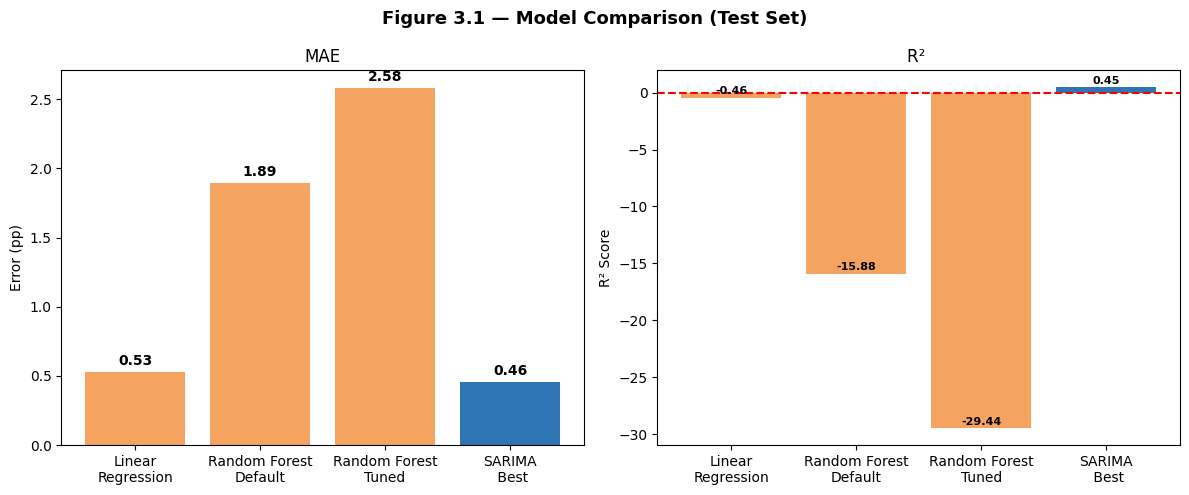

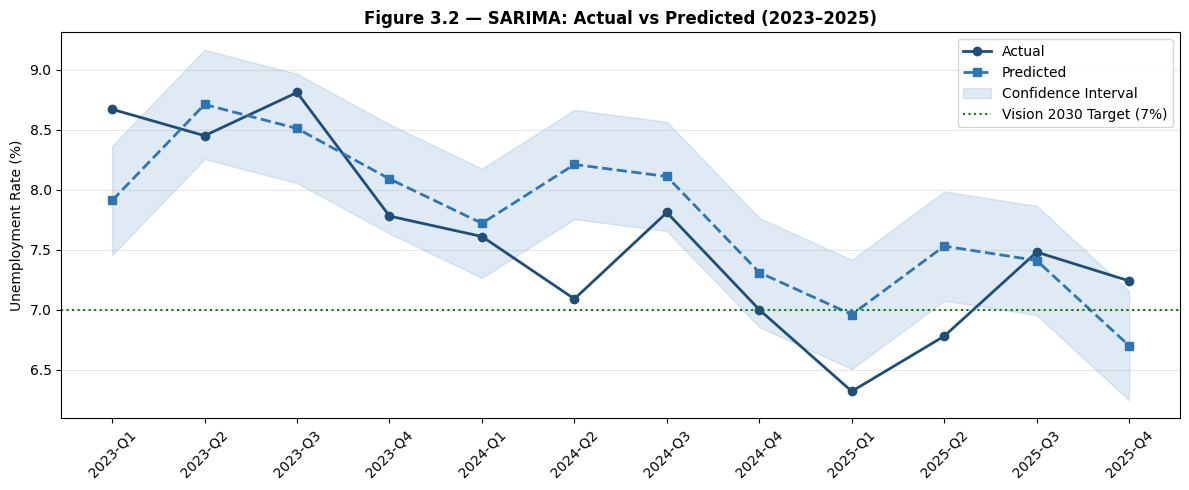

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#FIGURE 3.1: MODEL COMPARISON

models = ['Linear\nRegression', 'Random Forest\nDefault', 'Random Forest\nTuned', 'SARIMA\n Best']
mae_scores  = [0.5275, 1.8941, 2.5797, 0.4551]
r2_scores   = [-0.4584, -15.88, -29.44, 0.4524]
colors = ['#f4a460', '#f4a460', '#f4a460', '#2e75b6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 3.1 — Model Comparison (Test Set)', fontsize=13, fontweight='bold')

ax1.bar(models, mae_scores, color=colors)
ax1.set_title('MAE')
ax1.set_ylabel('Error (pp)')
for i, v in enumerate(mae_scores):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

ax2.bar(models, r2_scores, color=colors)
ax2.set_title('R² ')
ax2.set_ylabel('R² Score')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
for i, v in enumerate(r2_scores):
    ax2.text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()


# FIGURE 3.2: ACTUAL VS PREDICTED

quarters  = ['2023-Q1','2023-Q2','2023-Q3','2023-Q4',
             '2024-Q1','2024-Q2','2024-Q3','2024-Q4',
             '2025-Q1','2025-Q2','2025-Q3','2025-Q4']
actual    = [8.67, 8.45, 8.81, 7.78, 7.61, 7.09, 7.81, 7.00, 6.32, 6.78, 7.48, 7.24]
predicted = [7.91, 8.71, 8.51, 8.09, 7.72, 8.21, 8.11, 7.31, 6.96, 7.53, 7.41, 6.70]
mae = 0.4551

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Figure 3.2 — SARIMA: Actual vs Predicted (2023–2025)', fontsize=12, fontweight='bold')

ax.plot(quarters, actual,    color='#1f4e79', marker='o', linewidth=2, label='Actual')
ax.plot(quarters, predicted, color='#2e75b6', marker='s', linewidth=2, linestyle='--', label='Predicted')
ax.fill_between(quarters, [p - mae for p in predicted], [p + mae for p in predicted],
                alpha=0.15, color='#2e75b6', label='Confidence Interval')
ax.axhline(y=7.0, color='green', linestyle=':', linewidth=1.5, label='Vision 2030 Target (7%)')

ax.set_ylabel('Unemployment Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import json

#JSON
results = {
    "mae": float(sarima_mae),
    "rmse": float(sarima_rmse),
    "r2": float(sarima_r2),
    "historical_quarters": list(gender_data[gender_data['Gender']=='Total'].sort_values('Quarter')['Quarter'].values[-12:]),
    "historical_rates": list(gender_data[gender_data['Gender']=='Total'].sort_values('Quarter')['Unemployment Rate'].values[-12:]),
    "test_quarters": list(quarters_test),
    "actual_test": list(test_s),
    "predicted_test": list(forecast_s)
}

with open('/content/drive/MyDrive/unemployment_project/streamlit_app/results.json', 'w') as f:
    json.dump(results, f)

print("results.json saved!")

results.json saved!
